# Lasso Regression – House Price Prediction Baseline

This notebook trains a **Lasso Regression** model to predict `Tran_Pri`.  
Lasso (L1‑regularized linear regression) performs automatic feature selection by shrinking some coefficients exactly to zero, offering both interpretability and a sparse solution. Feature engineering is simplified for linear models, dropping high‑cardinality categorical keys to avoid dimension explosion.

## Workflow Summary

- Import libraries and set paths  
- Define parsing and helper functions  
- **Simplified feature engineering for linear regression**  
- Load and split data chronologically  
- Build features for train, holdout, and test  
- Preprocess (standardize numeric, one‑hot encode categorical)  
- Tune Lasso with `GridSearchCV` and `TimeSeriesSplit`  
- Evaluate and generate diagnostic charts  
- Interpretability: coefficient importance, SHAP beeswarm, PDP  
- Save model, metrics, and outputs

## 1. Imports and Configuration
This cell imports all required libraries and defines file paths and global constants.

In [ ]:
import re
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

import shap
import warnings
warnings.filterwarnings('ignore')


# Configuration constants
TARGET_COLUMN = "Tran_Pri"
RANDOM_STATE = 42
HOLDOUT_SIZE = 0.2

BASE_DIR = Path.cwd()
TRAIN_PATH = BASE_DIR.parent / "data" / "TRAIN.csv"
TEST_PATH = BASE_DIR.parent / "data" / "TEST.csv"
OUTPUT_DIR = BASE_DIR / "outputs_lasso"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Base directory:", BASE_DIR)
print("Training file exists:", TRAIN_PATH.exists(), TRAIN_PATH)
print("Test file exists:", TEST_PATH.exists(), TEST_PATH)

Base directory: d:\MACHINE LEARNING\knn_catboost\linear
Training file exists: True d:\MACHINE LEARNING\knn_catboost\data\TRAIN.csv
Test file exists: True d:\MACHINE LEARNING\knn_catboost\data\TEST.csv


## 2. Helper Functions
These utility functions parse text‑heavy columns and handle chronological splitting.

In [2]:
def parse_layout(layout: str) -> tuple[int, int, int, int]:
    """Extract room, livingroom, kitchen, and bathroom counts from layout text."""
    text = str(layout)
    counts = {}
    for part in ["Room", "Livingroom", "Kitchen", "Bathroom"]:
        match = re.search(rf"(\d+){part}", text)
        counts[part] = int(match.group(1)) if match else 0
    return (counts["Room"], counts["Livingroom"], counts["Kitchen"], counts["Bathroom"])

def parse_ea_ratio(value: str) -> tuple[float, float]:
    """Extract elevator and apartment counts from strings like '2E4A'."""
    match = re.match(r"(\d+)E(\d+)A", str(value))
    if not match:
        return np.nan, np.nan
    return float(match.group(1)), float(match.group(2))

def time_holdout_split(df: pd.DataFrame, holdout_size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Chronological split using Tran_Dt to prevent future data leakage."""
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    ordered_df = df.assign(_tran_dt=tran_dt).sort_values("_tran_dt").drop(columns="_tran_dt")
    split_idx = int(len(ordered_df) * (1 - holdout_size))
    return ordered_df.iloc[:split_idx].copy(), ordered_df.iloc[split_idx:].copy()

def calculate_metrics(actual: pd.Series, predicted: np.ndarray) -> dict:
    """Return RMSE, MAE, and R² as a dictionary."""
    return {
        "rmse": float(root_mean_squared_error(actual, predicted)),
        "mae": float(mean_absolute_error(actual, predicted)),
        "r2": float(r2_score(actual, predicted)),
    }

## 3. Feature Engineering – Simplified for Linear Regression
This function creates features suitable for Lasso. High‑cardinality keys are dropped to avoid an explosion of one‑hot encoded columns. Numeric transformations (log area, etc.) are retained.

In [3]:
def build_features_linear(df: pd.DataFrame, area_clip_bounds: tuple = None) -> tuple[pd.DataFrame, pd.Series, list, tuple]:
    """
    Create features suitable for linear regression.
    - Keeps numeric features and log transforms.
    - Drops high‑cardinality keys (Neigh, etc.) to avoid dimension explosion.
    - Retains broader categoricals: City, Reg, Dist, Build_Type, etc.
    """
    df = df.copy()
    
    # Parse date
    tran_dt = pd.to_datetime(df["Tran_Dt"], format="%Y.%m.%d", errors="coerce")
    df["Tran_Year"] = tran_dt.dt.year
    df["Tran_Month"] = tran_dt.dt.month
    
    # Clean build year and age
    built_year = pd.to_numeric(df["Build_Yr_Filled"], errors="coerce").clip(lower=1900, upper=2035)
    built_year = built_year.where(built_year <= df["Tran_Year"], df["Tran_Year"])
    df["Property_Age"] = (df["Tran_Year"] - built_year).clip(lower=0, upper=120)
    
    # Floor area clipping and log
    area = pd.to_numeric(df["Flo_Area"], errors="coerce")
    if area_clip_bounds is None:
        area_clip_bounds = (float(area.quantile(0.001)), float(area.quantile(0.995)))
    area_low, area_high = area_clip_bounds
    df["Flo_Area_Clipped"] = area.clip(lower=area_low, upper=area_high)
    df["Log_Flo_Area"] = np.log1p(df["Flo_Area_Clipped"])
    
    # Floor position ordinal
    floor_map = {"Lower floor": 1, "Middle floor": 2, "Upper floor": 3}
    df["Prop_Flo_Code"] = df["Prop_Flo"].map(floor_map).fillna(2)
    
    # Parse layout counts
    layout_parts = df["Layout"].apply(parse_layout)
    df["Layout_Rooms"] = layout_parts.str[0]
    df["Layout_Livingrooms"] = layout_parts.str[1]
    df["Layout_Kitchens"] = layout_parts.str[2]
    df["Layout_Bathrooms"] = layout_parts.str[3]
    
    # Parse elevator/apartment counts
    ea_parts = df["EA_Ratio"].apply(parse_ea_ratio)
    df["Elevator_Count"] = ea_parts.str[0]
    df["Apartment_Count"] = ea_parts.str[1]
    
    # Binary flags
    df["Lift_Flag"] = (df["Lift"].astype(str) == "Yes").astype(int)
    df["Has_Renovation"] = (df["ReNov"].astype(str) != "Unfurnished").astype(int)
    
    # Drop raw columns not used as features
    drop_cols = [
        "Tran_Dt", "Tran_Day", "Build_Yr", "Layout", "Prop_Flo",
        "Neigh",                           # too many categories
        "EA_Ratio", "Build_Yr_Filled", "Elevator_Density",
        "Total_Rooms",                     # redundant with Layout_Rooms
        "Tran_Year", "Tran_Month"
    ]
    
    # Target
    y = df[TARGET_COLUMN].copy()
    
    # Features
    X = df.drop(columns=[TARGET_COLUMN] + [c for c in drop_cols if c in df.columns], errors='ignore')
    
    # Identify categorical columns – only broader ones
    categorical_columns = [
        "City", "Reg", "Dist", "Build_Type", "Orient", "ReNov",
        "Build_Str", "Lift", "Prop_Type", "Build_Pur"
    ]
    categorical_columns = [c for c in categorical_columns if c in X.columns]
    
    # Fill missing and convert to string for encoding
    for col in categorical_columns:
        X[col] = X[col].fillna("Missing").astype(str)
    
    return X, y, categorical_columns, area_clip_bounds

## 4. Load Data and Split
Load raw CSV files and create a time‑based holdout split (80% train, 20% holdout).

In [4]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_split_df, holdout_df = time_holdout_split(train_df, HOLDOUT_SIZE)

print("Train period:", train_split_df["Tran_Dt"].iloc[0], "to", train_split_df["Tran_Dt"].iloc[-1])
print("Holdout period:", holdout_df["Tran_Dt"].iloc[0], "to", holdout_df["Tran_Dt"].iloc[-1])
print("Test period:", test_df["Tran_Dt"].iloc[0], "to", test_df["Tran_Dt"].iloc[-1])

Training shape: (165808, 23)
Test shape: (62733, 23)
Train period: 2012.11.22 to 2021.02.20
Holdout period: 2021.02.20 to 2021.06.30
Test period: 2021.07.01 to 2023.02.13


## 5. Build Features
Apply feature engineering to all three splits. Clipping bounds are learned from training and reused.

In [5]:
X_train, y_train, categorical_columns, area_clip_bounds = build_features_linear(train_split_df)
X_holdout, y_holdout, _, _ = build_features_linear(holdout_df, area_clip_bounds)
X_test, y_test, _, _ = build_features_linear(test_df, area_clip_bounds)

print("X_train shape:", X_train.shape)
print("X_holdout shape:", X_holdout.shape)
print("X_test shape:", X_test.shape)
print("Categorical columns:", categorical_columns)

X_train shape: (132646, 24)
X_holdout shape: (33162, 24)
X_test shape: (62733, 24)
Categorical columns: ['City', 'Reg', 'Dist', 'Build_Type', 'Orient', 'ReNov', 'Build_Str', 'Lift', 'Prop_Type', 'Build_Pur']


## 6. Preprocessing and Lasso Tuning
Build a pipeline that imputes, standardizes, and one‑hot encodes, then applies Lasso regression. The regularization strength alpha is tuned using time‑series cross‑validation.

In [6]:
# Separate numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_columns)
])

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Lasso(random_state=RANDOM_STATE, max_iter=5000))
])

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV score (negative MAE):", grid_search.best_score_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha: {'regressor__alpha': 0.1}
Best CV score (negative MAE): -673.4122179759541


## 7. Generate Predictions and Compute Metrics
Predict on all splits and calculate RMSE, MAE, and R².

In [7]:
train_pred = best_model.predict(X_train)
holdout_pred = best_model.predict(X_holdout)
test_pred = best_model.predict(X_test)

split_metrics = {
    "train": {"rows": len(X_train), **calculate_metrics(y_train, train_pred)},
    "holdout": {"rows": len(X_holdout), **calculate_metrics(y_holdout, holdout_pred)},
    "test": {"rows": len(X_test), **calculate_metrics(y_test, test_pred)},
}

comparison_df = pd.DataFrame.from_dict(split_metrics, orient="index").reset_index().rename(columns={"index": "split"})
comparison_df = comparison_df[["split", "rows", "rmse", "mae", "r2"]]
comparison_df

,split,rows,rmse,mae,r2
0,train,132646,869.235782,534.184832,0.697236
1,holdout,33162,1067.698398,604.330954,0.650745
2,test,62733,1162.520516,610.113989,0.640527


## 8. Evaluation Charts
Create scatter plot of actual vs predicted, residual histogram, and metrics bar chart.

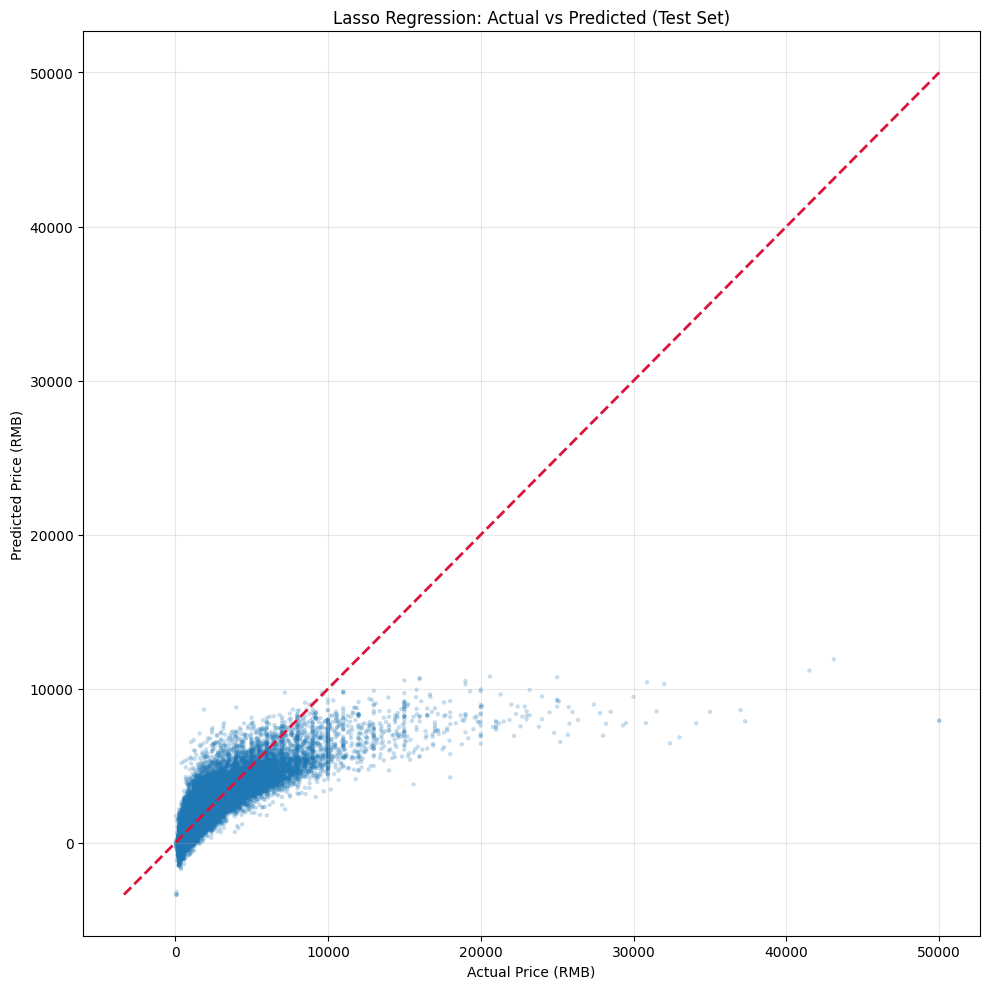

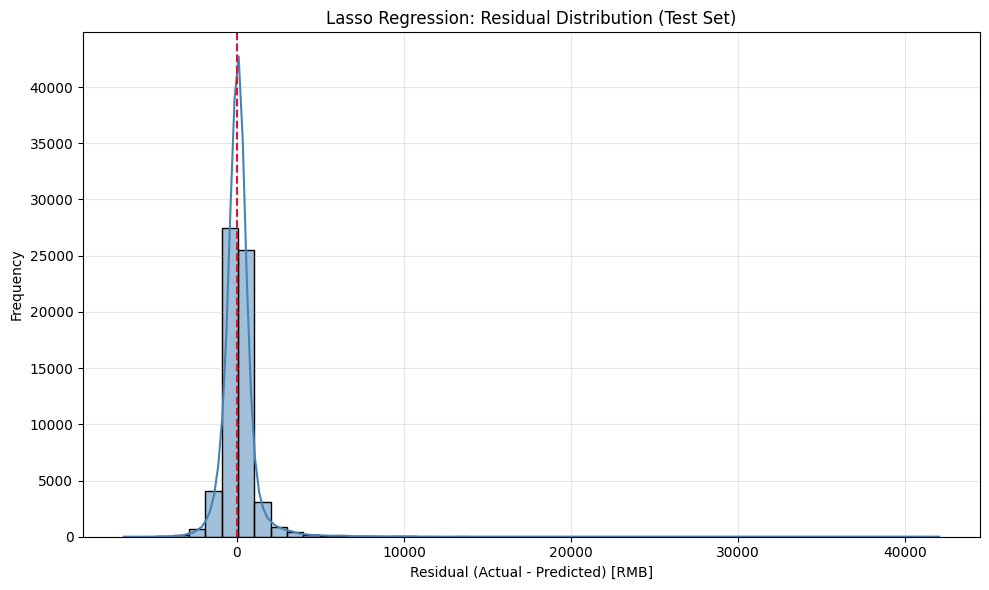

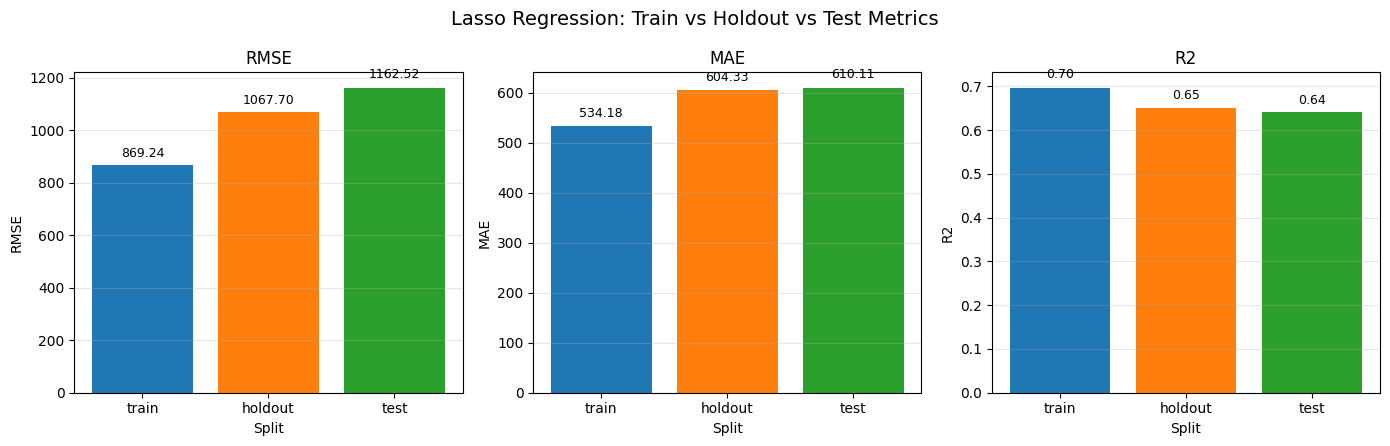

Charts saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_lasso


In [8]:
# Scatter: Actual vs Predicted (Test)
plt.figure(figsize=(10, 10))
plt.scatter(y_test, test_pred, alpha=0.25, s=10, edgecolors='none', rasterized=True)
min_val = min(y_test.min(), test_pred.min())
max_val = max(y_test.max(), test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--', linewidth=2, color='crimson')
plt.xlabel('Actual Price (RMB)')
plt.ylabel('Predicted Price (RMB)')
plt.title('Lasso Regression: Actual vs Predicted (Test Set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'actual_vs_predicted_scatter.png', dpi=220)
plt.show()
plt.close()

# Residual Histogram
residuals = y_test - test_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.axvline(x=0, color='crimson', linestyle='--', linewidth=1.5)
plt.xlabel('Residual (Actual - Predicted) [RMB]')
plt.ylabel('Frequency')
plt.title('Lasso Regression: Residual Distribution (Test Set)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'residual_histogram.png', dpi=220)
plt.show()
plt.close()

# Metrics Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
metrics = ['rmse', 'mae', 'r2']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for ax, metric in zip(axes, metrics):
    ax.bar(comparison_df['split'], comparison_df[metric], color=colors)
    ax.set_title(metric.upper())
    ax.set_xlabel('Split')
    ax.set_ylabel(metric.upper())
    ax.grid(axis='y', alpha=0.3)
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v + 0.02 * v, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
fig.suptitle('Lasso Regression: Train vs Holdout vs Test Metrics', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_bars.png', dpi=220)
plt.show()
plt.close()

print("Charts saved to:", OUTPUT_DIR)

## 9. Interpretability – Coefficients, SHAP, PDP
Compute Lasso coefficients (many will be zero), SHAP values using LinearExplainer, and Partial Dependence Plots.

Non‑zero coefficients: 299 out of 602


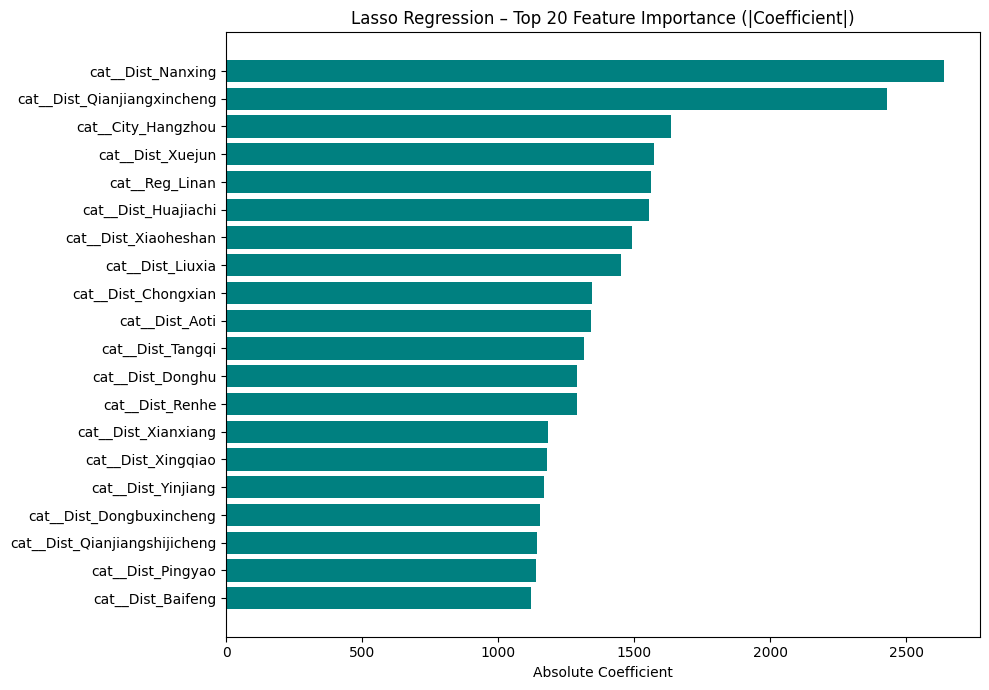

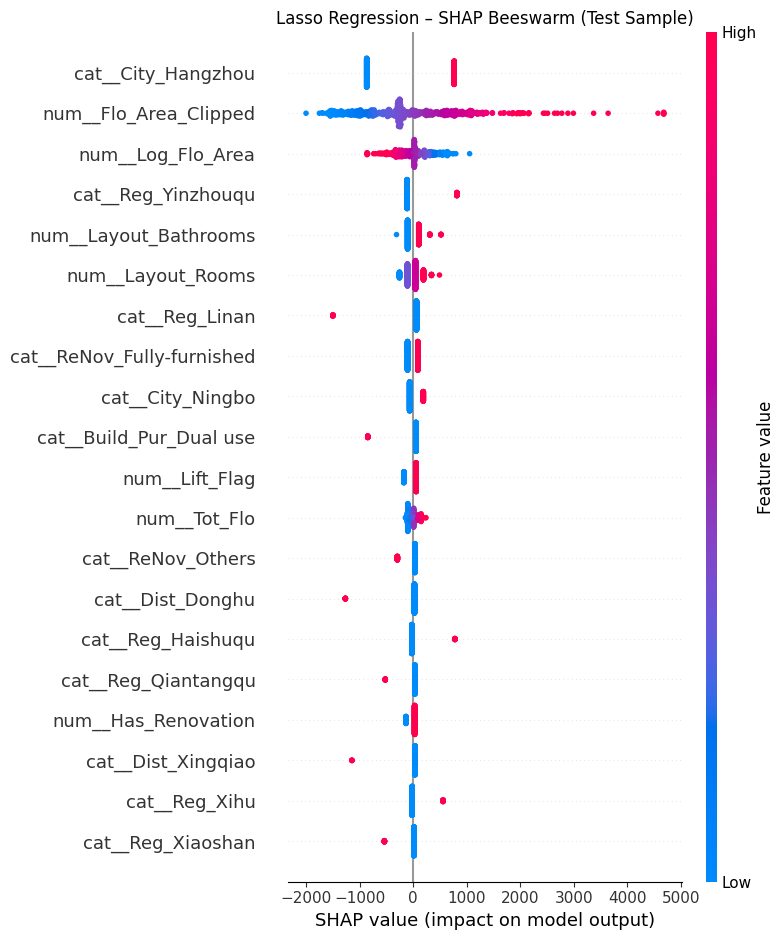

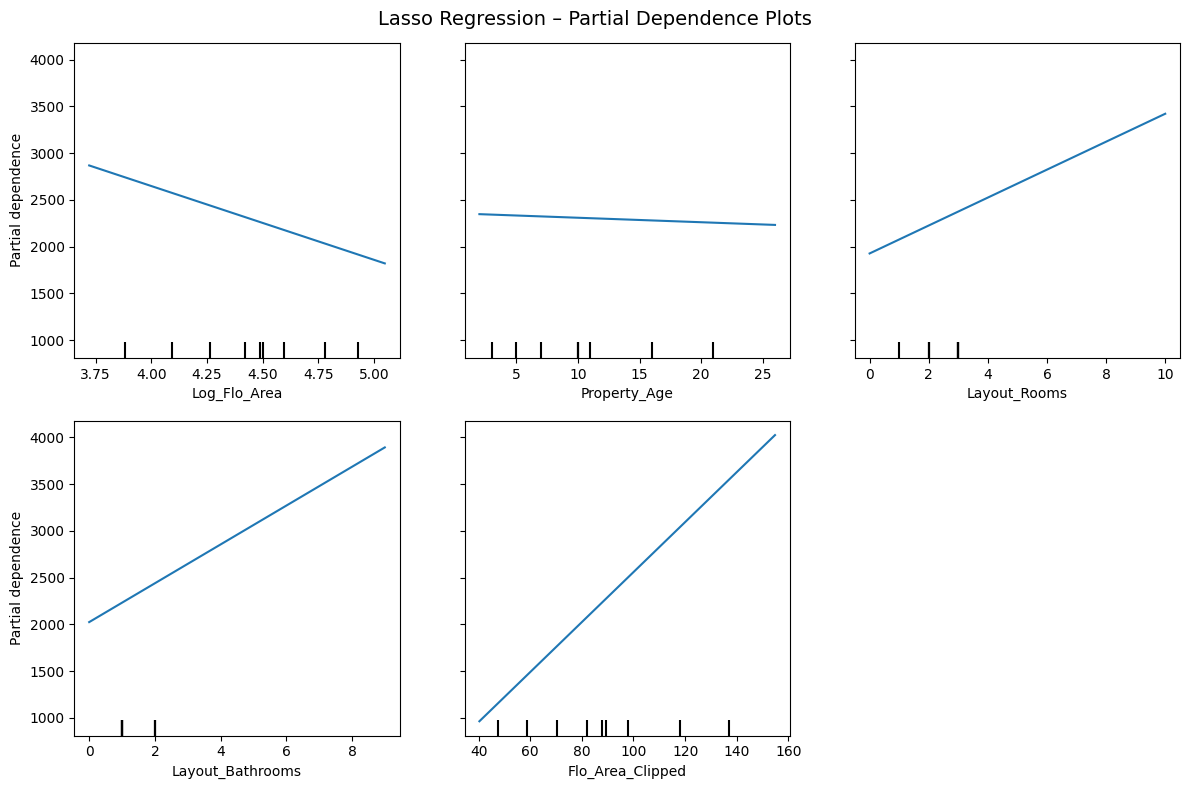

Interpretability outputs saved.


In [9]:
# Extract components
lasso_model = best_model.named_steps['regressor']
preprocessor = best_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

# Coefficient importance
coefs = lasso_model.coef_
nonzero_count = np.sum(coefs != 0)
print(f"Non‑zero coefficients: {nonzero_count} out of {len(coefs)}")

coef_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

coef_importance.to_csv(OUTPUT_DIR / 'lasso_coefficients.csv', index=False)

# Plot top 20 non‑zero coefficients
top_n = 20
plot_df = coef_importance.head(top_n).sort_values('abs_coef', ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['abs_coef'], color='teal')
plt.xlabel('Absolute Coefficient')
plt.title(f'Lasso Regression – Top {top_n} Feature Importance (|Coefficient|)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lasso_coefficient_importance.png', dpi=220)
plt.show()
plt.close()

# SHAP Beeswarm (LinearExplainer)
sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=RANDOM_STATE)
X_sample_transformed = preprocessor.transform(X_sample)

explainer = shap.LinearExplainer(lasso_model, X_sample_transformed)
shap_values = explainer.shap_values(X_sample_transformed)

explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample_transformed,
    feature_names=feature_names
)

plt.figure()
shap.summary_plot(explanation, X_sample_transformed, plot_type="dot", show=False)
plt.title("Lasso Regression – SHAP Beeswarm (Test Sample)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lasso_shap_beeswarm.png', dpi=220, bbox_inches="tight")
plt.show()
plt.close()

# Partial Dependence Plots for top numeric features
top_numeric = ['Log_Flo_Area', 'Property_Age', 'Layout_Rooms', 'Layout_Bathrooms', 'Flo_Area_Clipped']
top_numeric = [f for f in top_numeric if f in X_train.columns][:5]

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    best_model, X_train, top_numeric,
    kind='average', grid_resolution=30, ax=ax, n_jobs=-1
)
plt.suptitle('Lasso Regression – Partial Dependence Plots', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lasso_pdp.png', dpi=220)
plt.show()
plt.close()

print("Interpretability outputs saved.")

## 10. Save Outputs
Persist the trained model, preprocessing parameters, metrics, and predictions.

In [10]:
joblib.dump(best_model, OUTPUT_DIR / 'lasso_price_model.joblib')

preprocessing_info = {
    "feature_columns": X_train.columns.tolist(),
    "categorical_columns": categorical_columns,
    "numeric_features": numeric_features,
    "area_clip_bounds": area_clip_bounds,
    "target_column": TARGET_COLUMN,
}
with open(OUTPUT_DIR / 'preprocessing_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

comparison_df.to_csv(OUTPUT_DIR / 'metrics_comparison.csv', index=False)

test_predictions_df = pd.DataFrame({"actual": y_test, "predicted": test_pred})
test_predictions_df.to_csv(OUTPUT_DIR / 'actual_vs_predicted.csv', index=False)

test_with_pred = test_df.copy()
test_with_pred['predicted_tran_pri'] = test_pred
test_with_pred['residual'] = y_test - test_pred
test_with_pred.to_csv(OUTPUT_DIR / 'test_full_with_predictions.csv', index=False)

print("All outputs saved to:", OUTPUT_DIR)

All outputs saved to: d:\MACHINE LEARNING\knn_catboost\linear\outputs_lasso
